In [1]:
from google.colab import drive
import sys

drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/Colab Notebooks/ECE661/project_compression/resnet')

Mounted at /content/drive


In [2]:
#Imports
import argparse
import os, sys
import time
import datetime
from tqdm import tqdm_notebook as tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

## Model Setup: ResNet34 and ResNet50

### ResBlock Setup

In [3]:
class ResBlock(nn.Module):
  #Output channel multiplier
  expansion = 1

  def __init__(self, in_channels, out_channels, stride):
    super().__init__()

    #1st Layer: 3x3 Conv
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)

    #2nd Layer: 3x3 Conv
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)

    #Shortcut for dim matching
    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels:
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
            nn.BatchNorm2d(out_channels)
        )

  def forward(self, x):
    #1st Conv -> Batch Norm -> ReLU
    out = F.relu(self.bn1(self.conv1(x)))

    #2nd Conv -> Batch Norm
    out = self.bn2(self.conv2(out))

    #Shortcut (if needed)
    out += self.shortcut(x)

    #ReLU
    return F.relu(out)

### BottleneckBlock Setup

In [4]:
class BottleneckBlock(nn.Module):
  #Output channel multiplier
  expansion = 4

  def __init__(self, in_channels, out_channels, stride):
    super().__init__()

    #1st Layer: 1x1 Conv
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)

    #2nd Layer: 3x3 Conv
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)

    #3rd Layer: 1x1 Conv
    self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
    self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

    #Shortcut for dim matching
    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels * self.expansion:
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels * self.expansion)
    )

  def forward(self, x):
    #1st Conv -> Batch Norm -> ReLU
    out = F.relu(self.bn1(self.conv1(x)))

    #2nd Conv -> Batch Norm -> ReLU
    out = F.relu(self.bn2(self.conv2(out)))

    #3rd Conv -> Batch Norm
    out = self.bn3(self.conv3(out))

    #Shortcut (if needed)
    out += self.shortcut(x)

    #ReLU
    return F.relu(out)

### ResNet Setup

In [5]:
#Define ResNet

class ResNet(nn.Module):
  def __init__(self, block, layers, num_classes=10):
    super().__init__()

    #Initial channel number
    self.in_channels = 64

    #1st Conv Layer for CIFAR-10
    self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(64)

    #Residuals
    self.layer1 = self.make_layer(block, 64,  layers[0], stride=1)
    self.layer2 = self.make_layer(block, 128, layers[1], stride=2)
    self.layer3 = self.make_layer(block, 256, layers[2], stride=2)
    self.layer4 = self.make_layer(block, 512, layers[3], stride=2)

    #Pooling
    self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

    #Classification
    self.fc = nn.Linear(512 * block.expansion, num_classes)

  def make_layer(self, block, out_channels, num_blocks, stride):
    layers = []

    #First block with stride
    layers.append(block(self.in_channels, out_channels, stride))
    self.in_channels = out_channels * block.expansion

    #Remaining blocks have stride=1
    for _ in range(1, num_blocks):
      layers.append(block(self.in_channels, out_channels, stride=1))

    return nn.Sequential(*layers)

  def forward(self, x):
    #Initial Conv Layer -> Batch Norm -> ReLU
    out = F.relu(self.bn1(self.conv1(x)))

    out = self.layer1(out)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.layer4(out)

    #Reduce dim to 1x1
    out = self.global_avg_pool(out)
    out = torch.flatten(out, 1)

    #FC Layer then classify output
    out = self.fc(out)
    return F.log_softmax(out, dim=1)

In [21]:
def make_resnet34(num_classes=10):
    return ResNet(ResBlock, [3, 4, 6, 3], num_classes=num_classes)

def make_resnet50(num_classes=10):
    return ResNet(BottleneckBlock, [3, 4, 6, 3], num_classes=num_classes)

### ResNet34 Setup

In [7]:
#Define ResNet34
ResNet34 = make_resnet34()

#Check model summary
print(ResNet34)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

### ResNet50 Setup

In [26]:
#Define ResNet50
ResNet50 = make_resnet50()

#Check model summary
print(ResNet50)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BottleneckBlock(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): BottleneckBloc

## Preprocessing

In [9]:
import torchvision
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

#############################################
#Preprocessing function
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(16),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),
                         std=(0.2023, 0.1994, 0.2010)),
])
#############################################

### Set Up Dataset/Dataloader

In [10]:
#Get full dataset
full_train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform_train)

#Make train/val/test split: 45k/5k/10k
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

val_dataset.dataset.transform = transform_val
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform_val)

#Initialize dataloaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:06<00:00, 26.8MB/s]


### Send ResNet34, ResNet50 to Device

In [11]:
#############################################
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Chosen device: {device}')

resnet_34 = ResNet34.to(device)
resnet_50 = ResNet50.to(device)
#############################################

Chosen device: cuda


## ResNet34 Teacher: Train, Validate, Test

### Loss Function and Optimizer

In [12]:
import torch.nn as nn
import torch.optim as optim

#Hyperparameters
INITIAL_LR = 0.05
MOMENTUM = 0.9 #For optimizer
REG = 1e-5 #L2 regularization strength

#############################################
#Loss function
criterion = nn.CrossEntropyLoss()

#SGD Optimizer
optimizer = optim.SGD(resnet_34.parameters(), lr=INITIAL_LR, momentum=MOMENTUM, weight_decay=REG)
#############################################

### Train ResNet34

In [13]:
#Hyperparameters
EPOCHS = 100
DECAY_EPOCHS = 50
DECAY = 0.5

#Folder
CHECKPOINT_FOLDER = '/content/drive/MyDrive/Colab Notebooks/ECE661/project_compression/resnet'
os.makedirs(CHECKPOINT_FOLDER, exist_ok=True)

#Start training
best_val_acc = 0
current_learning_rate = INITIAL_LR
L1_lambda = 1e-4

print("==> Training starts!")
print("="*50)

#To log losses
resnet34_train_losses = []
resnet34_val_losses = []
resnet34_val_accuracies = []

for i in range(0, EPOCHS):
  ########################
  #Learning rate decay
  if i % DECAY_EPOCHS == 0 and i != 0:
    current_learning_rate *= DECAY
    for param_group in optimizer.param_groups:
      param_group['lr'] = current_learning_rate
    print(f"Learning rate decayed to {current_learning_rate:.6f}")
  #######################
  #Switch to train mode
  resnet_34.train()
  #######################

  print("Epoch %d:" %i)
  total_examples = 0
  correct_examples = 0
  train_loss = 0

  #Train the model
  for batch_idx, (inputs, targets) in enumerate(train_loader):
    ####################################
    #Copy inputs to device
    inputs = inputs.to(device)
    targets = targets.to(device)

    #Calculate output, loss
    output = resnet_34(inputs)
    loss = criterion(output, targets)

    #Update train_loss
    train_loss += loss.item()

    #Zero the gradient
    optimizer.zero_grad()

    #Backpropagation
    loss.backward()

    #Apply gradient and update the weights
    optimizer.step()

    #Count the number of correctly predicted samples in the current batch
    _, predicted = torch.max(output, dim=1)
    correct_examples += (predicted == targets).sum().item()
    total_examples += targets.size(0)

    ####################################

  avg_loss = train_loss / len(train_loader)
  avg_acc = correct_examples / total_examples
  print("Training loss: %.4f, Training accuracy: %.4f" %(avg_loss, avg_acc))

  #Append loss
  resnet34_train_losses.append(avg_loss)

  # Validate on the validation dataset
  #######################
  #Validation mode
  resnet_34.eval()

  #######################
  total_examples = 0
  correct_examples = 0
  val_loss = 0

  #Disable gradient during validation, which can save GPU memory
  with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(val_loader):
      ####################################
      #Copy inputs to device
      inputs = inputs.to(device)
      targets = targets.to(device)

      #Compute the output and loss
      output = resnet_34(inputs)
      loss = criterion(output, targets)

      #Update val_loss
      val_loss += loss.item()

      #Count the number of correctly predicted samples in the current batch
      _, predicted = torch.max(output, dim=1)
      correct_examples += (predicted == targets).sum().item()
      total_examples += targets.size(0)
      ####################################

  avg_loss = val_loss / len(val_loader)
  avg_acc = correct_examples / total_examples
  print("Validation loss: %.4f, Validation accuracy: %.4f" % (avg_loss, avg_acc))

  #Update values
  resnet34_val_losses.append(avg_loss)
  resnet34_val_accuracies.append(avg_acc)

  #Save the model checkpoint if it's a new best
  if avg_acc > best_val_acc:
    best_val_acc = avg_acc
    if not os.path.exists(CHECKPOINT_FOLDER):
      os.makedirs(CHECKPOINT_FOLDER)
    print("Saving ...")
    state = {'state_dict': resnet_34.state_dict(),
              'epoch': i,
              'lr': current_learning_rate}
    torch.save(state, os.path.join(CHECKPOINT_FOLDER, 'resnet34_teacher.pth'))

  print('')

print("="*50)
print(f"==> Optimization finished! Best validation accuracy: {best_val_acc:.4f}")

==> Training starts!
Epoch 0:
Training loss: 2.0972, Training accuracy: 0.2822
Validation loss: 1.6416, Validation accuracy: 0.3992
Saving ...

Epoch 1:
Training loss: 1.4975, Training accuracy: 0.4501
Validation loss: 1.3182, Validation accuracy: 0.5174
Saving ...

Epoch 2:
Training loss: 1.2635, Training accuracy: 0.5437
Validation loss: 1.1809, Validation accuracy: 0.5750
Saving ...

Epoch 3:
Training loss: 1.0783, Training accuracy: 0.6143
Validation loss: 0.9892, Validation accuracy: 0.6370
Saving ...

Epoch 4:
Training loss: 0.9285, Training accuracy: 0.6719
Validation loss: 0.9080, Validation accuracy: 0.6748
Saving ...

Epoch 5:
Training loss: 0.8045, Training accuracy: 0.7153
Validation loss: 0.8058, Validation accuracy: 0.7100
Saving ...

Epoch 6:
Training loss: 0.6789, Training accuracy: 0.7602
Validation loss: 0.7769, Validation accuracy: 0.7304
Saving ...

Epoch 7:
Training loss: 0.5849, Training accuracy: 0.7953
Validation loss: 0.8797, Validation accuracy: 0.7098

Epoch 

### Plot ResNet34 Training + Validation Results

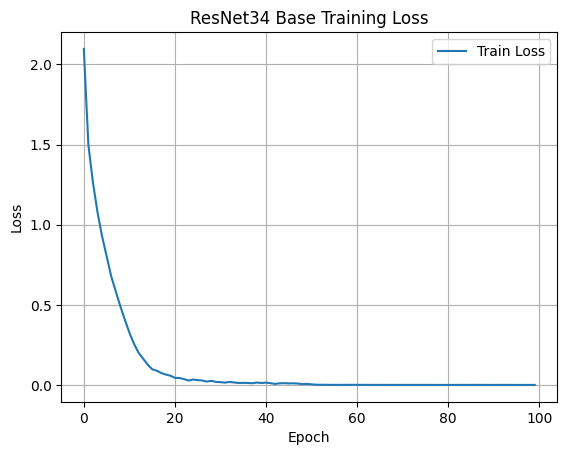

In [14]:
import matplotlib.pyplot as plt

#Training Loss
plt.figure()
plt.plot(resnet34_train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet34 Base Training Loss')
plt.grid(True)
plt.legend()
plt.show()

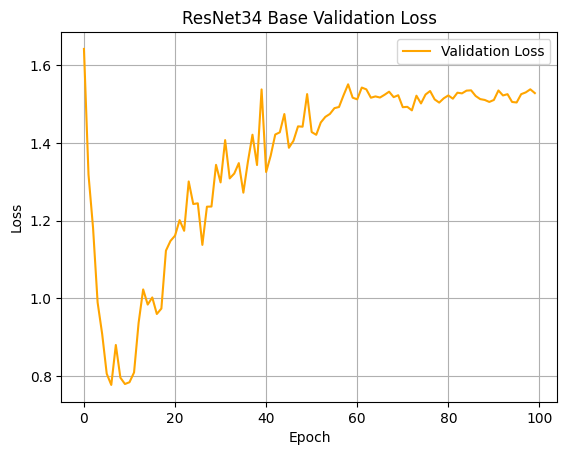

In [15]:
#Validation Loss
plt.figure()
plt.plot(resnet34_val_losses, label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet34 Base Validation Loss')
plt.grid(True)
plt.legend()
plt.show()

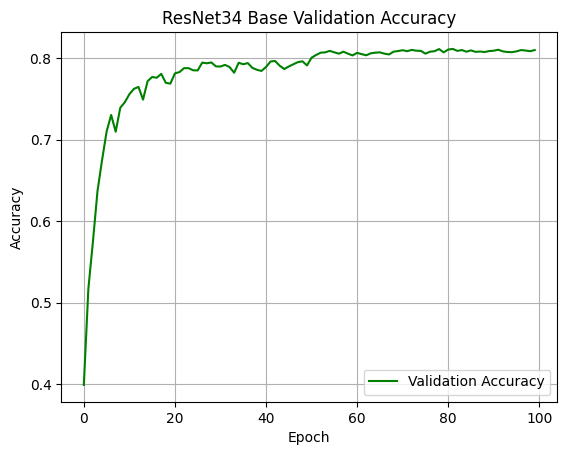

In [16]:
#Validation Accuracy
plt.figure()
plt.plot(resnet34_val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet34 Base Validation Accuracy')
plt.grid(True)
plt.legend()
plt.show()

### Test ResNet34

In [22]:
#Load trained model
resnet34_test = make_resnet34().to(device)
checkpoint = torch.load('/content/drive/MyDrive/Colab Notebooks/ECE661/project_compression/resnet/resnet34_teacher.pth')
resnet34_test.load_state_dict(checkpoint['state_dict'])

#Set to eval mode
resnet34_test.eval()

#Loss function
criterion = nn.CrossEntropyLoss()

#Log to keep track of values
test_loss = 0
correct = 0
total = 0
resnet34_all_preds = []
resnet34_all_targets = []

#Testing loop
with torch.no_grad():
  for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)

    #Forward pass
    outputs = resnet34_test(inputs)
    loss = criterion(outputs, targets)

    #Calculate loss
    test_loss += loss.item()
    _, pred = outputs.max(1)

    #Count how many predictions were correct
    correct += (pred== targets).sum().item()
    total += targets.size(0)

    #Update logs
    resnet34_all_preds.append(pred.cpu())
    resnet34_all_targets.append(targets.cpu())

#Update accuracy log
resnet34_avg_test_loss = test_loss / len(test_loader)
resnet34_test_accuracy = correct / total

#Final results
print(f'ResNet34 Test Loss: {resnet34_avg_test_loss:.4f}')
print(f'ResNet34 Test Accuracy: {resnet34_test_accuracy:.4f}')

ResNet34 Test Loss: 1.5693
ResNet34 Test Accuracy: 0.8030


## ResNet50 Student: Train, Validate, Test

### Loss Function and Optimizer

In [25]:
import torch.nn as nn
import torch.optim as optim

#Hyperparameters
INITIAL_LR = 0.05
MOMENTUM = 0.9 #For optimizer
REG = 1e-5 #L2 regularization strength

#############################################
#Loss function
criterion = nn.CrossEntropyLoss()

#SGD Optimizer
optimizer = optim.SGD(resnet_50.parameters(), lr=INITIAL_LR, momentum=MOMENTUM, weight_decay=REG)
#############################################

### Train ResNet50

In [ ]:
#Hyperparameters
EPOCHS = 100
DECAY_EPOCHS = 50
DECAY = 0.5

#Folder
CHECKPOINT_FOLDER = '/content/drive/MyDrive/Colab Notebooks/ECE661/project_compression/resnet'
os.makedirs(CHECKPOINT_FOLDER, exist_ok=True)

#Start training
best_val_acc = 0
current_learning_rate = INITIAL_LR
L1_lambda = 1e-4

print("==> Training starts!")
print("="*50)

#To log losses
resnet50_train_losses = []
resnet50_val_losses = []
resnet50_val_accuracies = []

for i in range(0, EPOCHS):
  ########################
  #Learning rate decay
  if i % DECAY_EPOCHS == 0 and i != 0:
    current_learning_rate *= DECAY
    for param_group in optimizer.param_groups:
      param_group['lr'] = current_learning_rate
    print(f"Learning rate decayed to {current_learning_rate:.6f}")
  #######################
  #Switch to train mode
  resnet_50.train()
  #######################

  print("Epoch %d:" %i)
  total_examples = 0
  correct_examples = 0
  train_loss = 0

  #Train the model
  for batch_idx, (inputs, targets) in enumerate(train_loader):
    ####################################
    #Copy inputs to device
    inputs = inputs.to(device)
    targets = targets.to(device)

    #Calculate output, loss
    output = resnet_50(inputs)
    loss = criterion(output, targets)

    #Update train_loss
    train_loss += loss.item()

    #Zero the gradient
    optimizer.zero_grad()

    #Backpropagation
    loss.backward()

    #Apply gradient and update the weights
    optimizer.step()

    #Count the number of correctly predicted samples in the current batch
    _, predicted = torch.max(output, dim=1)
    correct_examples += (predicted == targets).sum().item()
    total_examples += targets.size(0)

    ####################################

  avg_loss = train_loss / len(train_loader)
  avg_acc = correct_examples / total_examples
  print("Training loss: %.4f, Training accuracy: %.4f" %(avg_loss, avg_acc))

  #Append loss
  resnet50_train_losses.append(avg_loss)

  # Validate on the validation dataset
  #######################
  #Validation mode
  resnet_50.eval()

  #######################
  total_examples = 0
  correct_examples = 0
  val_loss = 0

  #Disable gradient during validation, which can save GPU memory
  with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(val_loader):
      ####################################
      #Copy inputs to device
      inputs = inputs.to(device)
      targets = targets.to(device)

      #Compute the output and loss
      output = resnet_50(inputs)
      loss = criterion(output, targets)

      #Update val_loss
      val_loss += loss.item()

      #Count the number of correctly predicted samples in the current batch
      _, predicted = torch.max(output, dim=1)
      correct_examples += (predicted == targets).sum().item()
      total_examples += targets.size(0)
      ####################################

  avg_loss = val_loss / len(val_loader)
  avg_acc = correct_examples / total_examples
  print("Validation loss: %.4f, Validation accuracy: %.4f" % (avg_loss, avg_acc))

  #Update values
  resnet50_val_losses.append(avg_loss)
  resnet50_val_accuracies.append(avg_acc)

  #Save the model checkpoint if it's a new best
  if avg_acc > best_val_acc:
    best_val_acc = avg_acc
    if not os.path.exists(CHECKPOINT_FOLDER):
      os.makedirs(CHECKPOINT_FOLDER)
    print("Saving ...")
    state = {'state_dict': resnet_50.state_dict(),
              'epoch': i,
              'lr': current_learning_rate}
    torch.save(state, os.path.join(CHECKPOINT_FOLDER, 'resnet50_base.pth'))

  print('')

print("="*50)
print(f"==> Optimization finished! Best validation accuracy: {best_val_acc:.4f}")

==> Training starts!
Epoch 0:


### Plot ResNet50 Training + Validation Results

In [ ]:
#Training Loss
plt.figure()
plt.plot(resnet34_train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet50 Base Training Loss')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#Validation Loss
plt.figure()
plt.plot(resnet34_val_losses, label='Validation Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ResNet50 Base Validation Loss')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#Validation Accuracy
plt.figure()
plt.plot(resnet34_val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ResNet50 Base Validation Accuracy')
plt.grid(True)
plt.legend()
plt.show()

### Test ResNet50

In [ ]:
#Load trained model
resnet50_test = ResNet50().to(device)
checkpoint = torch.load('/content/drive/MyDrive/Colab Notebooks/ECE661/project_compression/resnet/resnet50_base.pth')
resnet50_test.load_state_dict(checkpoint['state_dict'])

#Set to eval mode
resnet50_test.eval()

#Loss function
criterion = nn.CrossEntropyLoss()

#Log to keep track of values
test_loss = 0
correct = 0
total = 0
resnet50_all_preds = []
resnet50_all_targets = []

#Testing loop
with torch.no_grad():
  for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)

    #Forward pass
    outputs = resnet50_test(inputs)
    loss = criterion(outputs, targets)

    #Calculate loss
    test_loss += loss.item()
    _, pred = outputs.max(1)

    #Count how many predictions were correct
    correct += (pred== targets).sum().item()
    total += targets.size(0)

    #Update logs
    resnet50_all_preds.append(pred.cpu())
    resnet50_all_targets.append(targets.cpu())

#Update accuracy log
resnet50_avg_test_loss = test_loss / len(test_loader)
resnet50_test_accuracy = correct / total

#Final results
print(f'ResNet50 Test Loss: {resnet50_avg_test_loss:.4f}')
print(f'ResNet50 Test Accuracy: {resnet50_test_accuracy:.4f}')

## Distill ResNet34 Teacher -> ResNet50 Student

In [ ]:
from utils.pipeline import distill
from utils.losses import DistillationLoss
from utils.losses import Accuracy

#Initialize ResNet34 Teacher, ResNet50 student
teacher = ResNet34().to(device)
student = ResNet50().to(device)

#Load teacher checkpoint
checkpoint = torch.load('/content/drive/MyDrive/Colab Notebooks/ECE661/project_compression/resnet/resnet34_teacher.pth')
teacher.eval()

#Setup distillation loss
criterion = DistillationLoss(alpha=0.5, temperature=5.0)

#Setup optimizer, scheduler for ResNet50 Student
optimizer = torch.optim.SGD(student.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

#Perform distillation
distill_metrics = distill(train_loader, val_loader, teacher, student, criterion, optimizer, scheduler, device, Accuracy(), epochs=100)

#Save weights
save_path = '/content/drive/MyDrive/Colab Notebooks/ECE661/project_compression/resnet/resnet50_student.pth'
torch.save({
    'state_dict': student.state_dict(),
    'epoch': 100,
    'lr': optimizer.param_groups[0]['lr']
}, save_path)

print('Distilled ResNet50 Student Weights Saved')

### Plot ResNet50 Student Results

In [ ]:
#Plot training results for ResNet50 student
plot_training_metrics(distill_metrics)

## ResNet50 Self-Distillation

In [ ]:
#Load ResNet50 Teacher
self_distill_teacher = resnet50().to(device)
self_distill_teacher.load_state_dict(torch.load("models/weights/resnet50_student.pth")['state_dict'])
self_distill_teacher.eval()

self_distill_student = resnet50().to(device)

#Set up distillation loss
criterion = DistillationLoss(alpha=0.5, temperature=5.0)

#Set up optimizer, scheduler
optimizer = torch.optim.SGD(self_distill_student.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

self_distill_metrics = distill(train_loader, val_loader, self_distill_teacher, self_distill_student, criterion, optimizer, scheduler, device, Accuracy(), epochs=100)

#Save weights
save_path = '/content/drive/MyDrive/Colab Notebooks/ECE661/project_compression/resnet/resnet50_self_distill.pth'
torch.save({
    'state_dict': student.state_dict(),
    'epoch': 100,
    'lr': optimizer.param_groups[0]['lr']
}, save_path)

print('Self-Distilled ResNet50 Weights Saved')

### Plot ResNet50 Self-Distillation Results

In [ ]:
#Plot self-distillation results
plot_training_metrics(self_distill_metrics)